회귀모델

=== 데이터 첫 5행 ===
        Size         Price
0  24.981605  36495.505246
1  48.028572  54927.264367
2  39.279758  48663.076351
3  33.946339  37891.681719
4  16.240746  28145.618112

Size와 Price 간의 상관계수: 0.9632


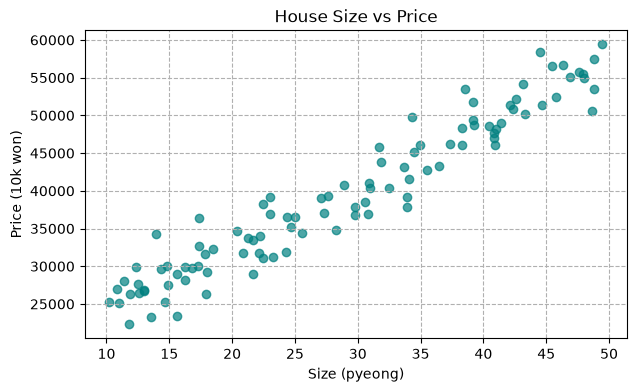

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. 재현성을 위한 난수 시드 설정
np.random.seed(42)

# 2. 데이터 생성: 평수(Size) 10~50평, 총 100세대
size = np.random.uniform(10, 50, 100)

# 주택 가격(Price): 기본 15000 + 평당 850 + 노이즈
price = 15000 + 850 * size + np.random.normal(0, 3000, 100)

df_house = pd.DataFrame({'Size': size, 'Price': price})
print("=== 데이터 첫 5행 ===")
print(df_house.head())

# 3. EDA: 산점도와 변수 간 상관계수 구하기
correlation = df_house['Size'].corr(df_house['Price'])
print(f"\nSize와 Price 간의 상관계수: {correlation:.4f}")

plt.figure(figsize=(7, 4))
plt.scatter(df_house['Size'], df_house['Price'], color='teal', alpha=0.7)
plt.title('House Size vs Price')
plt.xlabel('Size (pyeong)')
plt.ylabel('Price (10k won)')
plt.grid(True, linestyle='--')
plt.show()


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn import set_config

set_config(display="text")          # vscoode와 sklearn 사이 에러 발생 방지

In [5]:
# 특성과 타깃
x = df_house[["Size"]]          # 입력 데이터는 2차원 데이터!
y = df_house["Price"]

In [13]:
# 데이터 분할 => 8:2
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42
)

In [14]:
print(x_train.shape[0])
print(x_test.shape[0])

80
20


In [15]:
# 모델 선언 => 학습
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [16]:
# 기울기와 절편 확인
print("기울기 : ", model.coef_)
print("절편 : ", model.intercept_)

기울기 :  [819.89854862]
절편 :  15729.75447215528


In [17]:
# 모델에 대한 평가
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [23]:
# 테스트 데이터를 이용해서 예측값
# x_test, x_pred
# y_test, y_pred

y_pred = model.predict(x_test)

# 평가 지표 출력
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test,y_pred)

In [25]:
print("mse : ", mse)
print("rmse : ", rmse)
print("mae : ", mae)
print("r2 : ",r2)

mse :  5883295.623453015
rmse :  2425.550581507839
mae :  1774.0277337569337
r2 :  0.9446078584352587
